# Intelligent Microscopy for Materials

## Notebook 03 — Convolutional Neural Network from Scratch

### Objective

This notebook develops a convolutional neural network (CNN) for direct
classification of scanning electron microscopy (SEM) morphology.

Unlike the classical machine-learning pipeline in Notebook 02, which relied
on 1,841 engineered image descriptors, the CNN learns hierarchical visual
representations directly from the microscopy images.

The model is trained **from scratch**, without pretrained image-network
weights.

The fixed, leakage-controlled train, validation, and test partitions generated
in Notebook 01 are retained unchanged.

The principal question is whether learned image representations can outperform
the classical benchmark:

- Test accuracy: **0.7789**
- Test balanced accuracy: **0.6713**
- Test macro-F1: **0.6800**

Model selection is performed using the validation set. The test set remains
untouched until the CNN architecture and training strategy have been frozen.

## 1. Environment and Reproducibility

The deep-learning environment is initialized with fixed random seeds to improve
reproducibility.

GPU acceleration is used when available because CNN training requires
substantially more computation than the classical models evaluated previously.

In [ ]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 2. Load the Fixed Dataset Manifest

The CNN uses the exact train, validation, and test assignments established
during Notebook 01.

No new random split is generated in this notebook.

Maintaining identical partitions allows direct comparison between the
classical baseline, CNN-from-scratch model, and later transfer-learning
experiments.

In [ ]:
PROCESSED_DIR = Path(
    "/content/drive/MyDrive/"
    "intelligent-microscopy-materials/data/processed"
)

split_manifest = pd.read_csv(
    PROCESSED_DIR / "sem_split_manifest.csv"
)

print("Images:", len(split_manifest))
print("Classes:", split_manifest["class"].nunique())

print("\nSplit counts:")
display(
    split_manifest["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="images")
)

Images: 20742
Classes: 10

Split counts:


,split,images
0,train,14519
1,test,3112
2,validation,3111


In [ ]:
DATA_ROOT = Path("/content/sem_data")

print("Raw dataset currently available:", DATA_ROOT.exists())

Raw dataset currently available: False


## 3. Restore the SEM Image Dataset

The fixed dataset manifest is available, but the raw SEM images are not
present in the current Colab runtime.

Because `/content` storage is temporary, the ten source archives are restored
for this modelling session.

The archives are downloaded and extracted sequentially, and each archive is
deleted immediately after successful extraction to reduce temporary disk
usage.

The fixed 20,742-image manifest remains authoritative; no auditing,
deduplication, or dataset splitting is repeated.

In [ ]:
import tarfile

DATA_ROOT = Path("/content/sem_data")
ARCHIVE_ROOT = Path("/content/sem_archives")

DATA_ROOT.mkdir(parents=True, exist_ok=True)
ARCHIVE_ROOT.mkdir(parents=True, exist_ok=True)

BASE_URL = (
    "https://b2share.eudat.eu/records/"
    "zja8y-53j14/files"
)

DATASET_FILES = {
    "Fibres": "Fibres.tar",
    "Porous_Sponge": "Porous_Sponge.tar",
    "Films_Coated_Surface": "Films_Coated_Surface.tar",
    "Biological": "Biological.tar",
    "Tips": "Tips.tar",
    "Powder": "Powder.tar",
    "Nanowires": "Nanowires.tar",
    "Particles": "Particles.tar",
    "Patterned_surface": "Patterned_surface.tar",
    "MEMS_devices_and_electrodes":
        "MEMS_devices_and_electrodes.tar",
}

print("Dataset restoration environment ready.")

Dataset restoration environment ready.


In [ ]:
# Download and restore all ten classes

for folder_name, archive_name in DATASET_FILES.items():

    class_dir = DATA_ROOT / folder_name
    archive_path = ARCHIVE_ROOT / archive_name

    print("\n" + "=" * 70)
    print(f"Class: {folder_name}")

    if class_dir.exists():
        print("Already extracted — skipping.")
        continue

    url = f"{BASE_URL}/{archive_name}?download=1"

    print("Downloading...")

    !wget -q --show-progress -O "$archive_path" "$url"

    if (
        not archive_path.exists()
        or archive_path.stat().st_size == 0
    ):
        raise RuntimeError(
            f"Download failed: {archive_name}"
        )

    print("Extracting...")

    with tarfile.open(archive_path, "r") as tar:
        tar.extractall(DATA_ROOT)

    if not class_dir.exists():
        raise RuntimeError(
            f"Expected folder missing after extraction: "
            f"{folder_name}"
        )

    archive_path.unlink()

    print("Extraction complete.")
    print("Temporary archive deleted.")

print("\nAll ten morphology classes restored.")


Class: Fibres
Downloading...
/content/sem_archiv 100%[===================>]  77.23M  10.3MB/s    in 8.9s    
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Porous_Sponge
Downloading...


/tmp/ipykernel_3694/1383616368.py:32: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_ROOT)


/content/sem_archiv 100%[===================>] 114.02M  17.2MB/s    in 8.2s    
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Films_Coated_Surface
Downloading...
/content/sem_archiv 100%[===================>] 188.48M  7.29MB/s    in 20s     
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Biological
Downloading...
/content/sem_archiv 100%[===================>] 671.22M  6.45MB/s    in 75s     
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Tips
Downloading...
/content/sem_archiv 100%[===================>] 674.57M  16.5MB/s    in 40s     
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Powder
Downloading...
/content/sem_archiv 100%[===================>] 825.71M  15.4MB/s    in 54s     
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Nanowires
Downloading...
/content/sem_archiv 100%[===================>]   2.05G  16.6MB/s    in 2m 0s   
Extracting...
Extraction complete.
Tempor

### 3.1 Restoration Verification

Every image referenced by the fixed modelling manifest is checked against the
restored dataset before the CNN data pipeline is created.

All 20,742 required image paths must resolve successfully.

In [ ]:
split_manifest["runtime_path"] = (
    split_manifest["relative_path"]
    .apply(
        lambda p: str(DATA_ROOT / p)
    )
)

exists_mask = (
    split_manifest["runtime_path"]
    .apply(lambda p: Path(p).exists())
)

print(f"Required images: {len(split_manifest)}")
print(f"Images found:    {exists_mask.sum()}")
print(f"Missing images:  {(~exists_mask).sum()}")

Required images: 20742
Images found:    20742
Missing images:  0


## 4. CNN Image Pipeline

The CNN learns directly from SEM image pixels rather than from engineered
features.

The preprocessing strategy follows the decisions established during the
dataset audit:

1. retain the upper 78.125% of image height to remove the lower acquisition
   information strip;
2. convert the retained microscopy region to grayscale;
3. resize to a common **256 × 150 pixel** representation while preserving the
   approximate aspect ratio of the cropped SEM images;
4. apply moderate augmentation only to the training partition.

The validation and test images are not augmented.

Colored-overlay information identified in Notebook 01 is not supplied to the
CNN as a predictive feature.

In [ ]:
train_df = (
    split_manifest[
        split_manifest["split"] == "train"
    ]
    .reset_index(drop=True)
)

val_df = (
    split_manifest[
        split_manifest["split"] == "validation"
    ]
    .reset_index(drop=True)
)

test_df = (
    split_manifest[
        split_manifest["split"] == "test"
    ]
    .reset_index(drop=True)
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 14519
Validation: 3111
Test: 3112


### 4.2 Morphology-Class Encoding

The ten morphology labels are converted to integer class identifiers for
neural-network training.

The mapping is derived deterministically from the training classes and is
applied unchanged to validation and test images.

In [ ]:
class_names = sorted(
    train_df["class"].unique()
)

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Class mapping:")

for idx, class_name in idx_to_class.items():
    print(f"{idx}: {class_name}")

Class mapping:
0: Biological
1: Fibres
2: Films/Coated Surface
3: MEMS Devices/Electrodes
4: Nanowires
5: Particles
6: Patterned Surface
7: Porous/Sponge
8: Powder
9: Tips


In [ ]:
from torchvision import transforms

In [ ]:
CROP_RETAIN_FRACTION = 600 / 768

CNN_HEIGHT = 150
CNN_WIDTH = 256


def crop_sem_region(img):
    """
    Remove the lower SEM acquisition-information strip
    using the validated proportional crop.
    """

    crop_height = round(
        img.height * CROP_RETAIN_FRACTION
    )

    return img.crop(
        (0, 0, img.width, crop_height)
    )

In [ ]:
train_transform = transforms.Compose([
    transforms.Lambda(crop_sem_region),
    transforms.Grayscale(num_output_channels=1),

    transforms.Resize(
        (CNN_HEIGHT, CNN_WIDTH)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.ToTensor()
])


eval_transform = transforms.Compose([
    transforms.Lambda(crop_sem_region),
    transforms.Grayscale(num_output_channels=1),

    transforms.Resize(
        (CNN_HEIGHT, CNN_WIDTH)
    ),

    transforms.ToTensor()
])

### 4.4 PyTorch Dataset

A custom PyTorch Dataset links the fixed manifest entries to their restored
SEM image files.

Training images receive moderate augmentation, whereas validation and test
images undergo deterministic preprocessing only.

Each dataset item returns:

- the processed image tensor;
- the integer morphology label;
- the image relative path.

The relative path is retained for later error analysis and explainability.

In [ ]:
from PIL import Image


class SEMDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_idx
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = Path(
            row["runtime_path"]
        )

        with Image.open(image_path) as img:
            image = img.convert("RGB")

            if self.transform is not None:
                image = self.transform(img)

        label = self.class_to_idx[
            row["class"]
        ]

        return (
            image,
            label,
            row["relative_path"]
        )

In [ ]:
train_dataset = SEMDataset(
    train_df,
    train_transform,
    class_to_idx
)

val_dataset = SEMDataset(
    val_df,
    eval_transform,
    class_to_idx
)

test_dataset = SEMDataset(
    test_df,
    eval_transform,
    class_to_idx
)

print("Datasets rebuilt with finalized transforms.")

Datasets rebuilt with finalized transforms.


### 4.5 Visual Validation of CNN Inputs

Representative training images are inspected after preprocessing and
augmentation.

This verifies that:

- the lower SEM acquisition strip remains removed;
- grayscale morphology is preserved;
- resizing does not visibly distort the microscopy region;
- augmentation produces plausible SEM images rather than unrealistic
  structures.

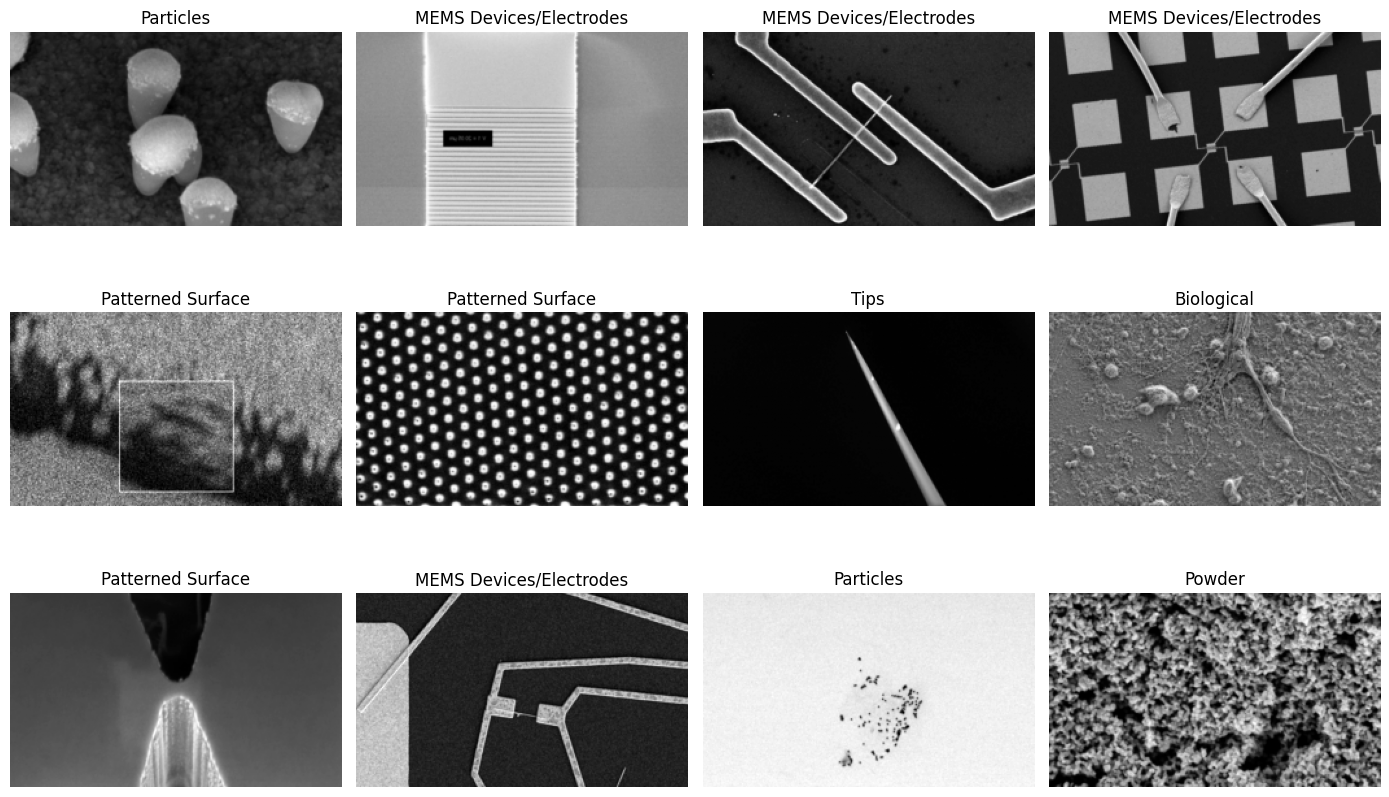

In [ ]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 9)
)

for ax in axes.flat:

    idx = np.random.randint(
        len(train_dataset)
    )

    image, label, _ = train_dataset[idx]

    ax.imshow(
        image.squeeze(0),
        cmap="gray"
    )

    ax.set_title(
        idx_to_class[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

### 4.6 Final Augmentation Validation

Visual inspection of the revised training transformations confirmed that the
SEM morphology remains physically plausible after preprocessing.

Horizontal and vertical flips preserve the underlying morphology without
introducing artificial image regions.

The previously tested arbitrary rotation augmentation was removed because it
introduced synthetic corner regions that could provide unintended cues to the
CNN.

The finalized baseline augmentation strategy therefore consists only of
horizontal and vertical flips applied to training images.

Annotations visible in some transformed images originate from the source SEM
micrographs and are not augmentation artifacts. Their influence will be
examined separately during model explainability and robustness analysis.

In [ ]:
# Verify the pre-normalization CNN input representation

preview_transform = transforms.Compose([
    transforms.Lambda(crop_sem_region),
    transforms.Grayscale(num_output_channels=1),

    transforms.Resize(
        (CNN_HEIGHT, CNN_WIDTH)
    ),

    transforms.ToTensor()
])

preview_dataset = SEMDataset(
    train_df,
    preview_transform,
    class_to_idx
)

sample_image, sample_label, sample_path = (
    preview_dataset[0]
)

print("Tensor shape:", sample_image.shape)
print("Data type:", sample_image.dtype)

print(
    "Pixel range:",
    float(sample_image.min()),
    "to",
    float(sample_image.max())
)

print(
    "Class:",
    idx_to_class[sample_label]
)

print(
    "Relative path:",
    sample_path
)

Tensor shape: torch.Size([1, 150, 256])
Data type: torch.float32
Pixel range: 0.09019608050584793 to 0.8784313797950745
Class: Fibres
Relative path: Fibres/L9_868551a78f03d7f5f119596a961d842d.jpg


## 5. Training-Set Intensity Normalization

Neural-network optimization is generally more stable when input intensities
are standardized.

The grayscale mean and standard deviation are estimated exclusively from the
training partition.

Validation and test images subsequently use these same training-derived
normalization parameters, preventing evaluation-set information from entering
the preprocessing pipeline.

In [ ]:
stats_transform = transforms.Compose([
    transforms.Lambda(crop_sem_region),
    transforms.Grayscale(num_output_channels=1),

    transforms.Resize(
        (CNN_HEIGHT, CNN_WIDTH)
    ),

    transforms.ToTensor()
])

stats_dataset = SEMDataset(
    train_df,
    stats_transform,
    class_to_idx
)

In [ ]:
stats_loader = DataLoader(
    stats_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Statistics loader ready.")

Statistics loader ready.


In [ ]:
pixel_sum = 0.0
pixel_squared_sum = 0.0
pixel_count = 0

for images, _, _ in stats_loader:

    pixel_sum += images.sum().item()
    pixel_squared_sum += (
        images ** 2
    ).sum().item()

    pixel_count += images.numel()


train_mean = pixel_sum / pixel_count

train_variance = (
    pixel_squared_sum / pixel_count
    - train_mean ** 2
)

train_std = train_variance ** 0.5

print(f"Training grayscale mean: {train_mean:.6f}")
print(f"Training grayscale std:  {train_std:.6f}")

Training grayscale mean: 0.388711
Training grayscale std:  0.240168


In [ ]:
train_transform = transforms.Compose([
    transforms.Lambda(crop_sem_region),
    transforms.Grayscale(num_output_channels=1),

    transforms.Resize(
        (CNN_HEIGHT, CNN_WIDTH)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[train_mean],
        std=[train_std]
    )
])


eval_transform = transforms.Compose([
    transforms.Lambda(crop_sem_region),
    transforms.Grayscale(num_output_channels=1),

    transforms.Resize(
        (CNN_HEIGHT, CNN_WIDTH)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[train_mean],
        std=[train_std]
    )
])

In [ ]:
train_dataset = SEMDataset(
    train_df,
    train_transform,
    class_to_idx
)

val_dataset = SEMDataset(
    val_df,
    eval_transform,
    class_to_idx
)

test_dataset = SEMDataset(
    test_df,
    eval_transform,
    class_to_idx
)

print("Final normalized datasets created.")

Final normalized datasets created.


In [ ]:
# Verify the final normalized CNN input

sample_image, sample_label, sample_path = (
    train_dataset[0]
)

print("Tensor shape:", sample_image.shape)
print("Data type:", sample_image.dtype)

print(
    "Normalized value range:",
    float(sample_image.min()),
    "to",
    float(sample_image.max())
)

print(
    "Class:",
    idx_to_class[sample_label]
)

print(
    "Relative path:",
    sample_path
)

Tensor shape: torch.Size([1, 150, 256])
Data type: torch.float32
Normalized value range: -1.2429428100585938 to 2.039078950881958
Class: Fibres
Relative path: Fibres/L9_868551a78f03d7f5f119596a961d842d.jpg


### 5.1 Final Normalization Result

Training-set intensity statistics were estimated exclusively from the
14,519 training images.

The resulting grayscale normalization parameters were:

- mean intensity: **0.388711**
- standard deviation: **0.240168**

These values are applied unchanged to training, validation, and test images.

The validation and test partitions therefore contribute no information to
normalization parameter estimation.

## 6. DataLoaders and Class-Imbalance Handling

The CNN training set remains strongly imbalanced across the ten morphology
classes.

Rather than artificially duplicating minority-class images through aggressive
oversampling, the baseline CNN retains the original training distribution and
uses a **class-weighted cross-entropy loss**.

Classes with fewer training examples therefore contribute more strongly to
the training objective, while every original training image remains represented
according to the fixed dataset split.

Validation and test data are never reweighted or resampled.

Mini-batches are shuffled only for the training partition.

In [ ]:
train_class_counts = (
    train_df["class"]
    .value_counts()
    .reindex(class_names)
)

display(
    train_class_counts
    .rename("training_images")
    .to_frame()
)

,training_images
class,
Biological,670
Fibres,105
Films/Coated Surface,211
MEMS Devices/Electrodes,3195
Nanowires,2610
Particles,2667
Patterned Surface,3249
Porous/Sponge,119
Powder,596


In [ ]:
# Calculate balanced class weights from training data only

num_classes = len(class_names)
num_training_images = len(train_df)

class_weights = (
    num_training_images
    / (
        num_classes
        * train_class_counts.to_numpy()
    )
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

class_weight_table = pd.DataFrame({
    "class": class_names,
    "training_images": train_class_counts.to_numpy(),
    "weight": class_weights
})

display(
    class_weight_table.round(4)
)

,class,training_images,weight
0,Biological,670,2.1670
1,Fibres,105,13.8276
2,Films/Coated Surface,211,6.8810
3,MEMS Devices/Electrodes,3195,0.4544
4,Nanowires,2610,0.5563
5,Particles,2667,0.5444
6,Patterned Surface,3249,0.4469
7,Porous/Sponge,119,12.2008
8,Powder,596,2.4361
9,Tips,1097,1.3235


In [ ]:
BATCH_SIZE = 64

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 227
Validation batches: 49
Test batches: 49


### 6.3 Mini-Batch Verification

One training mini-batch is inspected before model construction.

This verifies that the DataLoader produces the expected four-dimensional
tensor structure:

**batch × channel × height × width**

and that labels correspond to valid morphology-class indices.

In [ ]:
batch_images, batch_labels, batch_paths = next(
    iter(train_loader)
)

print("Image batch shape:", batch_images.shape)
print("Label batch shape:", batch_labels.shape)

print(
    "Image tensor type:",
    batch_images.dtype
)

print(
    "Label range:",
    int(batch_labels.min()),
    "to",
    int(batch_labels.max())
)

print(
    "Unique classes in this batch:",
    torch.unique(batch_labels).tolist()
)

Image batch shape: torch.Size([64, 1, 150, 256])
Label batch shape: torch.Size([64])
Image tensor type: torch.float32
Label range: 0 to 9
Unique classes in this batch: [0, 3, 4, 5, 6, 7, 8, 9]


## 7. Convolutional Neural Network Architecture

A convolutional neural network is constructed specifically for the
single-channel SEM morphology images used in this study.

The network is trained entirely from scratch without pretrained weights.

The architecture progressively learns increasingly abstract representations:

- early convolutional layers capture local edges and texture;
- intermediate layers learn larger morphology motifs;
- deeper layers combine these patterns into class-discriminative
  representations.

Each convolutional block includes:

- convolution;
- batch normalization;
- ReLU activation;
- max pooling.

Dropout is applied in the classifier to reduce overfitting.

Adaptive global average pooling is used before classification so that the
network does not depend on a large fully connected representation of the
entire spatial feature map.

The output layer contains ten units corresponding to the ten SEM morphology
classes.

In [ ]:
class SEMCNN(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                1, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(
                128, 256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                256,
                128
            ),
            nn.ReLU(inplace=True),

            nn.Dropout(
                p=0.4
            ),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x

In [ ]:
cnn_model = SEMCNN(
    num_classes=num_classes
).to(DEVICE)

print(cnn_model)

SEMCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affin

### 7.1 Architecture Verification

Before training, one mini-batch is passed through the CNN.

This verifies that the network accepts the expected
`batch × channel × height × width` input and returns one prediction vector
containing ten class scores for every image.

In [ ]:
batch_images = batch_images.to(DEVICE)

with torch.no_grad():

    batch_output = cnn_model(
        batch_images
    )

print(
    "Input shape:",
    batch_images.shape
)

print(
    "Output shape:",
    batch_output.shape
)

Input shape: torch.Size([64, 1, 150, 256])
Output shape: torch.Size([64, 10])


In [ ]:
total_parameters = sum(
    p.numel()
    for p in cnn_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in cnn_model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

Total parameters: 422,986
Trainable parameters: 422,986


## 8. CNN Training Configuration

The CNN is trained using class-weighted cross-entropy loss to account for the
substantial imbalance among morphology classes.

Optimization uses AdamW, which combines adaptive gradient updates with weight
decay for regularization.

The validation **macro-F1 score** is used as the principal model-selection
criterion because it gives equal importance to all ten morphology classes
regardless of class frequency.

Training incorporates:

- class-weighted cross-entropy loss;
- AdamW optimization;
- validation-based learning-rate reduction;
- early stopping;
- automatic mixed-precision training on the GPU;
- persistent checkpointing of the best validation model.

The independent test partition remains untouched during CNN development.

In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Loss, optimizer, and scheduler configured.")

Loss, optimizer, and scheduler configured.


In [ ]:
CNN_MODEL_DIR = Path(
    "/content/drive/MyDrive/"
    "intelligent-microscopy-materials/models/cnn_scratch"
)

CNN_RESULTS_DIR = Path(
    "/content/drive/MyDrive/"
    "intelligent-microscopy-materials/results/cnn_scratch"
)

CNN_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CNN_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    CNN_MODEL_DIR / "best_cnn_scratch.pt"
)

print("Best-model checkpoint:", BEST_MODEL_PATH)

Best-model checkpoint: /content/drive/MyDrive/intelligent-microscopy-materials/models/cnn_scratch/best_cnn_scratch.pt


In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    scaler
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)


def evaluate_model(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels, _ in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    all_labels = np.asarray(all_labels)
    all_predictions = np.asarray(
        all_predictions
    )

    validation_loss = (
        running_loss / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "loss": validation_loss,
        "accuracy": accuracy,
        "balanced_accuracy":
            balanced_accuracy,
        "macro_f1": macro_f1
    }

In [ ]:
amp_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda")
)

print("Training functions ready.")

Training functions ready.


### 8.6 Validation-Guided Training and Early Stopping

The CNN is trained for a maximum number of epochs while monitoring validation
macro-F1 after every epoch.

The model achieving the highest validation macro-F1 is saved as the final
candidate model.

Early stopping terminates training when validation macro-F1 fails to improve
for several consecutive epochs, reducing unnecessary computation and limiting
overfitting.

Both the best model and the most recent training state are written to
persistent Google Drive storage so that an interrupted Colab session can be
recovered without restarting training from the beginning.

The test partition is not evaluated during this process.

In [ ]:
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 6

LAST_CHECKPOINT_PATH = (
    CNN_MODEL_DIR / "last_cnn_scratch_checkpoint.pt"
)

HISTORY_PATH = (
    CNN_RESULTS_DIR / "cnn_training_history.csv"
)

best_val_macro_f1 = -np.inf
epochs_without_improvement = 0

training_history = []

print("Maximum epochs:", MAX_EPOCHS)
print(
    "Early-stopping patience:",
    EARLY_STOPPING_PATIENCE
)

Maximum epochs: 30
Early-stopping patience: 6


In [44]:
for epoch in range(1, MAX_EPOCHS + 1):

    # --------------------------------------------------
    # Train
    # --------------------------------------------------

    train_loss, train_accuracy = train_one_epoch(
        cnn_model,
        train_loader,
        criterion,
        optimizer,
        DEVICE,
        amp_scaler
    )

    # --------------------------------------------------
    # Validate
    # --------------------------------------------------

    val_metrics = evaluate_model(
        cnn_model,
        val_loader,
        criterion,
        DEVICE
    )

    val_loss = val_metrics["loss"]
    val_accuracy = val_metrics["accuracy"]

    val_balanced_accuracy = (
        val_metrics["balanced_accuracy"]
    )

    val_macro_f1 = val_metrics["macro_f1"]

    # --------------------------------------------------
    # Learning-rate schedule
    # --------------------------------------------------

    scheduler.step(
        val_macro_f1
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # --------------------------------------------------
    # Record history
    # --------------------------------------------------

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_balanced_accuracy":
            val_balanced_accuracy,
        "val_macro_f1": val_macro_f1,
        "learning_rate": current_lr
    }

    training_history.append(
        epoch_record
    )

    pd.DataFrame(
        training_history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )

    # --------------------------------------------------
    # Check for validation improvement
    # --------------------------------------------------

    improved = (
        val_macro_f1
        > best_val_macro_f1
    )

    if improved:

        best_val_macro_f1 = (
            val_macro_f1
        )

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    cnn_model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "val_macro_f1":
                    val_macro_f1,
                "val_balanced_accuracy":
                    val_balanced_accuracy,
                "val_accuracy":
                    val_accuracy,
                "class_to_idx":
                    class_to_idx,
                "train_mean":
                    train_mean,
                "train_std":
                    train_std
            },
            BEST_MODEL_PATH
        )

        status = "BEST MODEL SAVED"

    else:

        epochs_without_improvement += 1
        status = "no improvement"

    # --------------------------------------------------
    # Save latest training state
    # --------------------------------------------------

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict":
                cnn_model.state_dict(),
            "optimizer_state_dict":
                optimizer.state_dict(),
            "scheduler_state_dict":
                scheduler.state_dict(),
            "best_val_macro_f1":
                best_val_macro_f1,
            "epochs_without_improvement":
                epochs_without_improvement,
            "training_history":
                training_history
        },
        LAST_CHECKPOINT_PATH
    )

    # --------------------------------------------------
    # Epoch report
    # --------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train loss {train_loss:.4f} | "
        f"Train acc {train_accuracy:.4f} | "
        f"Val loss {val_loss:.4f} | "
        f"Val acc {val_accuracy:.4f} | "
        f"Val bal acc "
        f"{val_balanced_accuracy:.4f} | "
        f"Val macro-F1 "
        f"{val_macro_f1:.4f} | "
        f"LR {current_lr:.2e} | "
        f"{status}"
    )

    # --------------------------------------------------
    # Early stopping
    # --------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        print(
            f"Best validation macro-F1: "
            f"{best_val_macro_f1:.4f}"
        )

        break

Epoch 01/30 | Train loss 1.9232 | Train acc 0.2978 | Val loss 1.9015 | Val acc 0.2944 | Val bal acc 0.3110 | Val macro-F1 0.2350 | LR 1.00e-03 | BEST MODEL SAVED
Epoch 02/30 | Train loss 1.6496 | Train acc 0.4206 | Val loss 1.5914 | Val acc 0.4237 | Val bal acc 0.3760 | Val macro-F1 0.3290 | LR 1.00e-03 | BEST MODEL SAVED
Epoch 03/30 | Train loss 1.5280 | Train acc 0.4561 | Val loss 1.6009 | Val acc 0.4243 | Val bal acc 0.4277 | Val macro-F1 0.3324 | LR 1.00e-03 | BEST MODEL SAVED
Epoch 04/30 | Train loss 1.4593 | Train acc 0.4684 | Val loss 1.5523 | Val acc 0.4339 | Val bal acc 0.4908 | Val macro-F1 0.3553 | LR 1.00e-03 | BEST MODEL SAVED
Epoch 05/30 | Train loss 1.3957 | Train acc 0.4929 | Val loss 1.2997 | Val acc 0.5429 | Val bal acc 0.5388 | Val macro-F1 0.4460 | LR 1.00e-03 | BEST MODEL SAVED
Epoch 06/30 | Train loss 1.3168 | Train acc 0.5281 | Val loss 1.3207 | Val acc 0.5320 | Val bal acc 0.5810 | Val macro-F1 0.4490 | LR 1.00e-03 | BEST MODEL SAVED
Epoch 07/30 | Train loss 1.2

### 8.7 Training Extension to Convergence

The initial 30-epoch training window ended with the strongest validation
macro-F1 occurring at the final epoch.

This indicates that optimization had not clearly reached a plateau when the
initial epoch limit was reached.

Training is therefore continued from the existing epoch-30 model, optimizer,
scheduler, and early-stopping state rather than restarting or modifying the
architecture.

The maximum training horizon is extended to 45 epochs while retaining the same
validation macro-F1 selection criterion and six-epoch early-stopping patience.

The independent test set remains untouched.

In [45]:
EXTENDED_MAX_EPOCHS = 45

for epoch in range(31, EXTENDED_MAX_EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        cnn_model,
        train_loader,
        criterion,
        optimizer,
        DEVICE,
        amp_scaler
    )

    val_metrics = evaluate_model(
        cnn_model,
        val_loader,
        criterion,
        DEVICE
    )

    val_loss = val_metrics["loss"]
    val_accuracy = val_metrics["accuracy"]
    val_balanced_accuracy = val_metrics["balanced_accuracy"]
    val_macro_f1 = val_metrics["macro_f1"]

    scheduler.step(val_macro_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_balanced_accuracy": val_balanced_accuracy,
        "val_macro_f1": val_macro_f1,
        "learning_rate": current_lr
    }

    training_history.append(epoch_record)

    pd.DataFrame(training_history).to_csv(
        HISTORY_PATH,
        index=False
    )

    improved = val_macro_f1 > best_val_macro_f1

    if improved:

        best_val_macro_f1 = val_macro_f1
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": cnn_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_macro_f1": val_macro_f1,
                "val_balanced_accuracy": val_balanced_accuracy,
                "val_accuracy": val_accuracy,
                "class_to_idx": class_to_idx,
                "train_mean": train_mean,
                "train_std": train_std
            },
            BEST_MODEL_PATH
        )

        status = "BEST MODEL SAVED"

    else:
        epochs_without_improvement += 1
        status = "no improvement"

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": cnn_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_macro_f1": best_val_macro_f1,
            "epochs_without_improvement": epochs_without_improvement,
            "training_history": training_history
        },
        LAST_CHECKPOINT_PATH
    )

    print(
        f"Epoch {epoch:02d}/{EXTENDED_MAX_EPOCHS} | "
        f"Train loss {train_loss:.4f} | "
        f"Train acc {train_accuracy:.4f} | "
        f"Val loss {val_loss:.4f} | "
        f"Val acc {val_accuracy:.4f} | "
        f"Val bal acc {val_balanced_accuracy:.4f} | "
        f"Val macro-F1 {val_macro_f1:.4f} | "
        f"LR {current_lr:.2e} | "
        f"{status}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        print("\nEarly stopping triggered.")
        print(
            f"Best validation macro-F1: "
            f"{best_val_macro_f1:.4f}"
        )
        break

Epoch 31/45 | Train loss 0.6061 | Train acc 0.7429 | Val loss 0.7550 | Val acc 0.7351 | Val bal acc 0.7752 | Val macro-F1 0.6507 | LR 2.50e-04 | no improvement
Epoch 32/45 | Train loss 0.5866 | Train acc 0.7472 | Val loss 0.7445 | Val acc 0.7480 | Val bal acc 0.7881 | Val macro-F1 0.6563 | LR 2.50e-04 | no improvement
Epoch 33/45 | Train loss 0.5898 | Train acc 0.7474 | Val loss 0.6728 | Val acc 0.7647 | Val bal acc 0.7877 | Val macro-F1 0.6913 | LR 1.25e-04 | no improvement
Epoch 34/45 | Train loss 0.5638 | Train acc 0.7556 | Val loss 0.6732 | Val acc 0.7670 | Val bal acc 0.7932 | Val macro-F1 0.6862 | LR 1.25e-04 | no improvement
Epoch 35/45 | Train loss 0.5571 | Train acc 0.7561 | Val loss 0.6803 | Val acc 0.7653 | Val bal acc 0.8063 | Val macro-F1 0.6899 | LR 1.25e-04 | no improvement
Epoch 36/45 | Train loss 0.5403 | Train acc 0.7578 | Val loss 0.6616 | Val acc 0.7715 | Val bal acc 0.7951 | Val macro-F1 0.6956 | LR 1.25e-04 | BEST MODEL SAVED
Epoch 37/45 | Train loss 0.5416 | Trai

### 8.8 Final Training Extension

Validation performance continued to improve through epoch 45, where the
highest validation macro-F1 reached 0.7127.

The same training run is therefore allowed one final extension to a maximum
of 60 epochs.

No architecture, augmentation, loss function, optimizer, or model-selection
criterion is changed.

Early stopping remains active with a patience of six epochs. Training will
terminate earlier if validation macro-F1 stops improving.

After this extension, training is considered complete and the checkpoint with
the highest validation macro-F1 is used for final evaluation.

In [46]:
FINAL_MAX_EPOCHS = 60

for epoch in range(46, FINAL_MAX_EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        cnn_model,
        train_loader,
        criterion,
        optimizer,
        DEVICE,
        amp_scaler
    )

    val_metrics = evaluate_model(
        cnn_model,
        val_loader,
        criterion,
        DEVICE
    )

    val_loss = val_metrics["loss"]
    val_accuracy = val_metrics["accuracy"]
    val_balanced_accuracy = val_metrics["balanced_accuracy"]
    val_macro_f1 = val_metrics["macro_f1"]

    scheduler.step(val_macro_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_balanced_accuracy": val_balanced_accuracy,
        "val_macro_f1": val_macro_f1,
        "learning_rate": current_lr
    }

    training_history.append(epoch_record)

    pd.DataFrame(training_history).to_csv(
        HISTORY_PATH,
        index=False
    )

    improved = val_macro_f1 > best_val_macro_f1

    if improved:

        best_val_macro_f1 = val_macro_f1
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": cnn_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_macro_f1": val_macro_f1,
                "val_balanced_accuracy": val_balanced_accuracy,
                "val_accuracy": val_accuracy,
                "class_to_idx": class_to_idx,
                "train_mean": train_mean,
                "train_std": train_std
            },
            BEST_MODEL_PATH
        )

        status = "BEST MODEL SAVED"

    else:

        epochs_without_improvement += 1
        status = "no improvement"

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": cnn_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_macro_f1": best_val_macro_f1,
            "epochs_without_improvement": epochs_without_improvement,
            "training_history": training_history
        },
        LAST_CHECKPOINT_PATH
    )

    print(
        f"Epoch {epoch:02d}/{FINAL_MAX_EPOCHS} | "
        f"Train loss {train_loss:.4f} | "
        f"Train acc {train_accuracy:.4f} | "
        f"Val loss {val_loss:.4f} | "
        f"Val acc {val_accuracy:.4f} | "
        f"Val bal acc {val_balanced_accuracy:.4f} | "
        f"Val macro-F1 {val_macro_f1:.4f} | "
        f"LR {current_lr:.2e} | "
        f"{status}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        print("\nEarly stopping triggered.")
        print(
            f"Best validation macro-F1: "
            f"{best_val_macro_f1:.4f}"
        )
        break

Epoch 46/60 | Train loss 0.5041 | Train acc 0.7718 | Val loss 0.6454 | Val acc 0.7808 | Val bal acc 0.8155 | Val macro-F1 0.7088 | LR 6.25e-05 | no improvement
Epoch 47/60 | Train loss 0.5022 | Train acc 0.7731 | Val loss 0.6456 | Val acc 0.7811 | Val bal acc 0.8130 | Val macro-F1 0.7148 | LR 6.25e-05 | BEST MODEL SAVED
Epoch 48/60 | Train loss 0.5037 | Train acc 0.7743 | Val loss 0.6378 | Val acc 0.7779 | Val bal acc 0.8032 | Val macro-F1 0.7015 | LR 6.25e-05 | no improvement
Epoch 49/60 | Train loss 0.5107 | Train acc 0.7780 | Val loss 0.6589 | Val acc 0.7766 | Val bal acc 0.7992 | Val macro-F1 0.6985 | LR 6.25e-05 | no improvement
Epoch 50/60 | Train loss 0.5011 | Train acc 0.7746 | Val loss 0.6374 | Val acc 0.7814 | Val bal acc 0.8146 | Val macro-F1 0.7071 | LR 3.13e-05 | no improvement
Epoch 51/60 | Train loss 0.4938 | Train acc 0.7790 | Val loss 0.6348 | Val acc 0.7801 | Val bal acc 0.8121 | Val macro-F1 0.7127 | LR 3.13e-05 | no improvement
Epoch 52/60 | Train loss 0.4951 | Trai

### 8.9 Final CNN Training Result

Training converged through validation-guided learning-rate reduction and early
stopping.

Early stopping was triggered at epoch 59 after six consecutive epochs without
an improvement in validation macro-F1.

The best model occurred at **epoch 53**, achieving a validation macro-F1 of
**0.7165**.

The best checkpoint was saved independently of the final training state and is
used for all subsequent evaluation.

Compared with the classical Histogram Gradient Boosting baseline, the
CNN-from-scratch achieved higher validation accuracy, balanced accuracy, and
macro-F1, indicating that learned image representations provide additional
discriminatory information beyond the engineered classical descriptors.

No test-set predictions were examined during CNN training or model selection.

## 9. Best-Checkpoint Recovery and Training Analysis

The model state producing the highest validation macro-F1 is restored from
persistent storage.

Using the best checkpoint rather than the final training epoch ensures that
subsequent evaluation corresponds exactly to the model selected by the
predefined validation criterion.

In [48]:
# Load the trusted best validation checkpoint

best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

cnn_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

cnn_model = cnn_model.to(DEVICE)
cnn_model.eval()

print("Best checkpoint loaded.")

print(
    "Best epoch:",
    best_checkpoint["epoch"]
)

print(
    "Validation accuracy:",
    f"{best_checkpoint['val_accuracy']:.4f}"
)

print(
    "Validation balanced accuracy:",
    f"{best_checkpoint['val_balanced_accuracy']:.4f}"
)

print(
    "Validation macro-F1:",
    f"{best_checkpoint['val_macro_f1']:.4f}"
)

Best checkpoint loaded.
Best epoch: 53
Validation accuracy: 0.7875
Validation balanced accuracy: 0.8090
Validation macro-F1: 0.7165


In [49]:
history_df = pd.read_csv(
    HISTORY_PATH
)

print("Recorded epochs:", len(history_df))

display(
    history_df.tail()
)

Recorded epochs: 59


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,learning_rate
54,55,0.492215,0.777051,0.639772,0.780456,0.804222,0.700699,0.000031
55,56,0.490065,0.777464,0.634564,0.781099,0.805299,0.703562,0.000016
56,57,0.485183,0.779255,0.625810,0.781742,0.808228,0.709924,0.000016
57,58,0.486126,0.776155,0.627734,0.781742,0.809268,0.707701,0.000016
58,59,0.478404,0.779530,0.634123,0.782707,0.813883,0.711995,0.000008


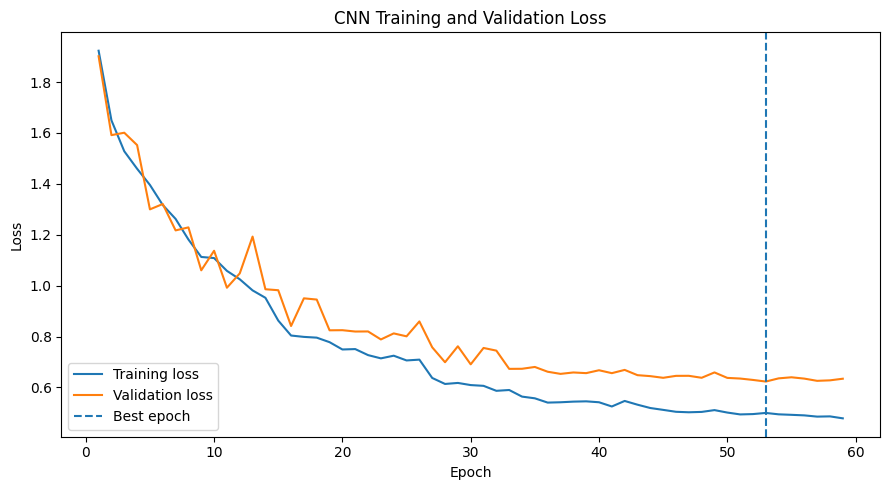

In [50]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_checkpoint["epoch"],
    linestyle="--",
    label="Best epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")

plt.legend()
plt.tight_layout()
plt.show()

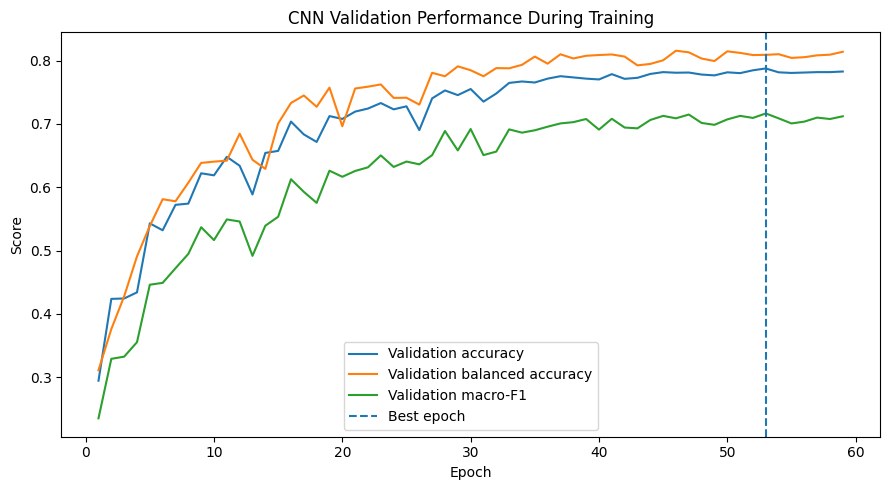

In [51]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_balanced_accuracy"],
    label="Validation balanced accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    label="Validation macro-F1"
)

plt.axvline(
    best_checkpoint["epoch"],
    linestyle="--",
    label="Best epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("CNN Validation Performance During Training")

plt.legend()
plt.tight_layout()
plt.show()

In [52]:
best_val_metrics = evaluate_model(
    cnn_model,
    val_loader,
    criterion,
    DEVICE
)

print("Restored Best CNN — Validation Performance")
print("------------------------------------------")
print(
    f"Accuracy:          "
    f"{best_val_metrics['accuracy']:.4f}"
)
print(
    f"Balanced accuracy: "
    f"{best_val_metrics['balanced_accuracy']:.4f}"
)
print(
    f"Macro F1:          "
    f"{best_val_metrics['macro_f1']:.4f}"
)

Restored Best CNN — Validation Performance
------------------------------------------
Accuracy:          0.7875
Balanced accuracy: 0.8090
Macro F1:          0.7165


### 9.1 Training-Convergence Interpretation

The best CNN checkpoint occurred at epoch 53.

Training loss decreased steadily throughout optimization, while validation
loss declined substantially before reaching a relatively stable plateau.

Validation accuracy, balanced accuracy, and macro-F1 improved progressively
during training and subsequently stabilized, motivating validation-guided
checkpoint selection and early stopping.

The restored epoch-53 model achieved:

- validation accuracy: **0.7875**
- validation balanced accuracy: **0.8090**
- validation macro-F1: **0.7165**

Compared with the classical Histogram Gradient Boosting baseline, the
CNN-from-scratch produced substantial improvements in balanced accuracy and
macro-F1, indicating better recognition across the imbalanced morphology
classes.

The test partition has remained untouched during model development.

## 10. Validation Per-Class Analysis

The selected CNN is examined at class level before final test evaluation.

Per-class precision, recall, and F1 scores reveal whether improvements in
balanced accuracy arise broadly across morphology classes or remain
concentrated in a subset of categories.

A normalized confusion matrix is also used to identify systematic morphology
confusions.

In [53]:
def collect_predictions(
    model,
    loader,
    device
):
    model.eval()

    all_labels = []
    all_predictions = []
    all_paths = []

    with torch.no_grad():

        for images, labels, paths in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            predictions = outputs.argmax(
                dim=1
            )

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_paths.extend(paths)

    return (
        np.asarray(all_labels),
        np.asarray(all_predictions),
        np.asarray(all_paths)
    )


cnn_val_true, cnn_val_pred, cnn_val_paths = (
    collect_predictions(
        cnn_model,
        val_loader,
        DEVICE
    )
)

print(
    "Validation predictions collected:",
    len(cnn_val_pred)
)

Validation predictions collected: 3111


In [54]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

cnn_val_report = classification_report(
    cnn_val_true,
    cnn_val_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

cnn_val_report_df = (
    pd.DataFrame(cnn_val_report)
    .transpose()
)

display(
    cnn_val_report_df[
        ["precision", "recall", "f1-score", "support"]
    ].round(3)
)

,precision,recall,f1-score,support
Biological,0.698,0.888,0.782,143.000
Fibres,0.367,0.783,0.500,23.000
Films/Coated Surface,0.372,0.778,0.504,45.000
MEMS Devices/Electrodes,0.852,0.782,0.816,685.000
Nanowires,0.913,0.805,0.856,559.000
Particles,0.859,0.823,0.841,571.000
Patterned Surface,0.805,0.705,0.752,696.000
Porous/Sponge,0.468,0.846,0.603,26.000
Powder,0.789,0.875,0.830,128.000
Tips,0.594,0.804,0.684,235.000


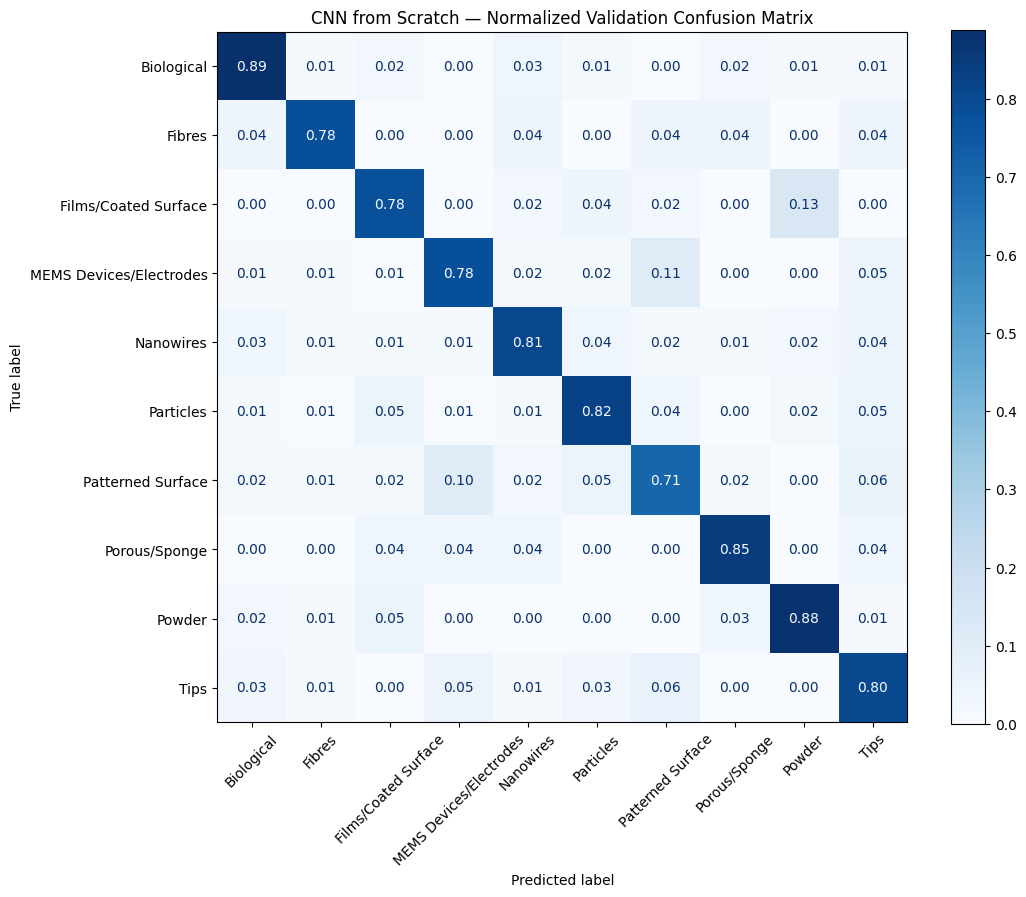

In [55]:
cnn_val_cm = confusion_matrix(
    cnn_val_true,
    cnn_val_pred,
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_val_cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45
)

plt.title(
    "CNN from Scratch — "
    "Normalized Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

### 10.1 Interpretation of CNN Validation Performance

The CNN-from-scratch demonstrated substantially more balanced recognition
across morphology classes than the classical feature-based models.

Particularly notable improvements occurred for minority classes. Fibres,
Films/Coated Surface, and Porous/Sponge achieved recalls of approximately
0.78, 0.78, and 0.84, respectively.

The class-weighted training objective therefore succeeded in increasing
sensitivity to underrepresented morphologies.

For some minority classes, increased recall was accompanied by lower
precision. Fibres, for example, achieved high recall but comparatively low
precision, indicating that some images from other classes were incorrectly
assigned to the Fibres category.

Overall, the normalized confusion matrix shows strong diagonal structure
across all ten classes. The improvement in balanced accuracy is therefore
broadly distributed rather than arising exclusively from the largest
morphology classes.

The CNN architecture and training strategy are now frozen before evaluation
on the independent test partition.

## 11. Final CNN Evaluation on the Held-Out Test Set

The CNN architecture, preprocessing strategy, training configuration, and
best checkpoint were selected without examining test-set predictions.

The frozen epoch-53 model is now evaluated once on the independent 3,112-image
test partition.

These results provide the final generalization estimate for the
CNN-from-scratch model and allow direct comparison with the classical
Histogram Gradient Boosting benchmark.

In [56]:
# Collect final predictions from the untouched test partition

cnn_test_true, cnn_test_pred, cnn_test_paths = (
    collect_predictions(
        cnn_model,
        test_loader,
        DEVICE
    )
)

print(
    "Test predictions collected:",
    len(cnn_test_pred)
)

Test predictions collected: 3112


In [57]:
cnn_test_accuracy = accuracy_score(
    cnn_test_true,
    cnn_test_pred
)

cnn_test_balanced_accuracy = balanced_accuracy_score(
    cnn_test_true,
    cnn_test_pred
)

cnn_test_macro_f1 = f1_score(
    cnn_test_true,
    cnn_test_pred,
    average="macro",
    zero_division=0
)

print("CNN from Scratch — Final Test Performance")
print("-----------------------------------------")
print(
    f"Accuracy:          "
    f"{cnn_test_accuracy:.4f}"
)
print(
    f"Balanced accuracy: "
    f"{cnn_test_balanced_accuracy:.4f}"
)
print(
    f"Macro F1:          "
    f"{cnn_test_macro_f1:.4f}"
)

CNN from Scratch — Final Test Performance
-----------------------------------------
Accuracy:          0.7947
Balanced accuracy: 0.8421
Macro F1:          0.7425


In [58]:
cnn_test_report = classification_report(
    cnn_test_true,
    cnn_test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

cnn_test_report_df = (
    pd.DataFrame(cnn_test_report)
    .transpose()
)

display(
    cnn_test_report_df[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].round(3)
)

,precision,recall,f1-score,support
Biological,0.790,0.917,0.849,144.000
Fibres,0.426,0.909,0.580,22.000
Films/Coated Surface,0.352,0.822,0.493,45.000
MEMS Devices/Electrodes,0.840,0.756,0.796,685.000
Nanowires,0.907,0.821,0.862,559.000
Particles,0.888,0.860,0.874,572.000
Patterned Surface,0.802,0.697,0.746,697.000
Porous/Sponge,0.571,0.960,0.716,25.000
Powder,0.787,0.836,0.811,128.000
Tips,0.596,0.843,0.698,235.000


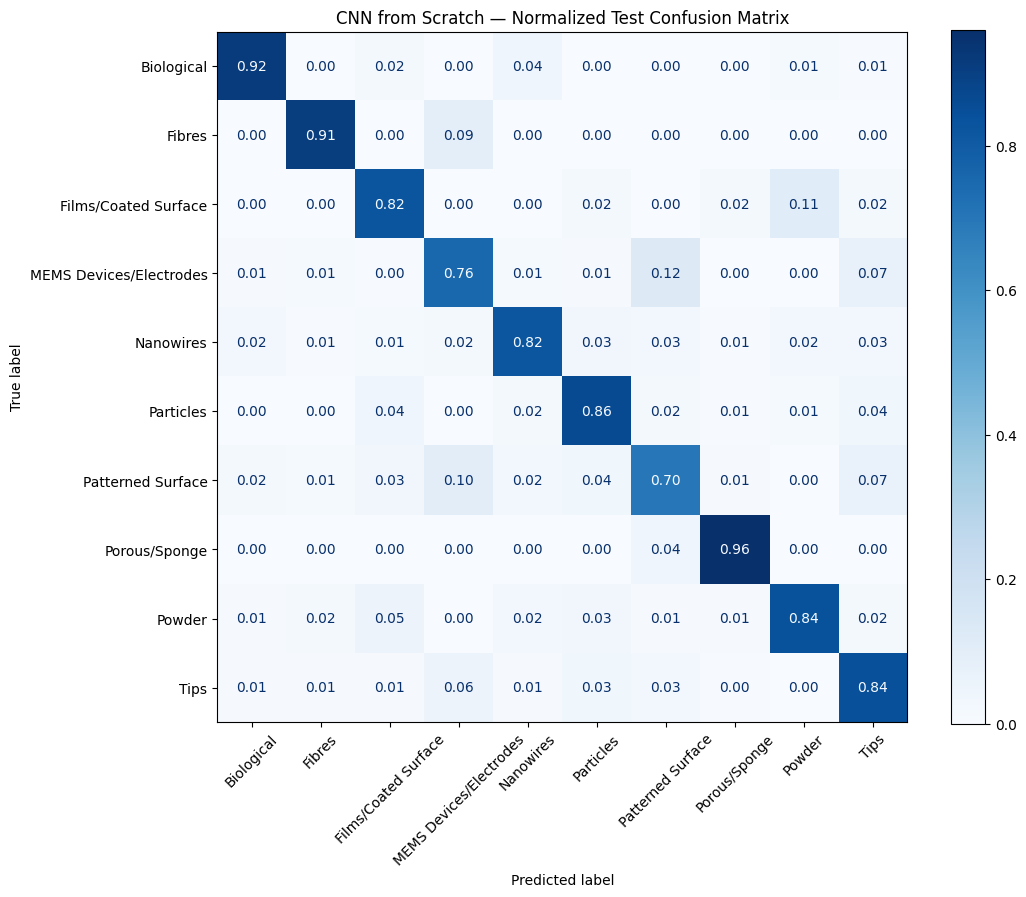

In [59]:
cnn_test_cm = confusion_matrix(
    cnn_test_true,
    cnn_test_pred,
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_test_cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45
)

plt.title(
    "CNN from Scratch — "
    "Normalized Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

### 11.1 Final CNN Test Result

The frozen CNN-from-scratch model achieved the following performance on the
independent 3,112-image test partition:

- **Accuracy:** 0.7947
- **Balanced accuracy:** 0.8421
- **Macro-F1:** 0.7425

The CNN therefore outperformed the classical Histogram Gradient Boosting
benchmark, which achieved a test accuracy of 0.7789, balanced accuracy of
0.6713, and macro-F1 of 0.6800.

The largest improvement occurred in balanced accuracy, indicating substantially
better recognition across the strongly imbalanced morphology classes.

Minority-class recall was particularly strong. Fibres, Films/Coated Surface,
and Porous/Sponge achieved recalls of approximately 0.91, 0.82, and 0.96,
respectively.

However, high minority-class sensitivity was accompanied by lower precision
for several underrepresented classes. This reflects the class-weighted
training objective, which penalizes minority-class errors more strongly and
can therefore increase false-positive assignments to these categories.

Overall, the test results demonstrate that directly learned CNN
representations capture SEM morphology more effectively than the engineered
feature representation used by the classical baseline.

In [60]:
model_test_comparison = pd.DataFrame([
    {
        "model": "Histogram Gradient Boosting",
        "accuracy": 0.7789,
        "balanced_accuracy": 0.6713,
        "macro_f1": 0.6800
    },
    {
        "model": "CNN from Scratch",
        "accuracy": cnn_test_accuracy,
        "balanced_accuracy": cnn_test_balanced_accuracy,
        "macro_f1": cnn_test_macro_f1
    }
])

display(
    model_test_comparison.round(4)
)

,model,accuracy,balanced_accuracy,macro_f1
0,Histogram Gradient Boosting,0.7789,0.6713,0.6800
1,CNN from Scratch,0.7947,0.8421,0.7425


## 12. Classical versus CNN Benchmark

The CNN-from-scratch surpassed the selected classical baseline on all three
held-out test metrics.

The gain in overall accuracy was modest, whereas improvements in balanced
accuracy and macro-F1 were substantially larger.

This distinction is important because overall accuracy is dominated by the
most frequent morphology classes. The stronger balanced accuracy and
macro-F1 therefore provide evidence that the CNN learned more useful
representations for the minority classes rather than merely improving
majority-class predictions.

## 13. Artifact-Stratified CNN Test Performance

The frozen CNN is evaluated separately on test images flagged as potential
colored-overlay candidates and images without detected colored overlays.

This is a descriptive robustness analysis only. No model parameters,
preprocessing decisions, or training settings are modified after examining
these results.

In [61]:
test_manifest_df = pd.read_csv(
    PROCESSED_DIR / "test_manifest.csv"
)

test_lookup = (
    test_manifest_df
    .set_index("relative_path")
)

cnn_test_results_df = pd.DataFrame({
    "relative_path": cnn_test_paths,
    "true_label": cnn_test_true,
    "predicted_label": cnn_test_pred
})

cnn_test_results_df["colored_overlay_candidate"] = (
    cnn_test_results_df["relative_path"]
    .map(
        test_lookup["colored_overlay_candidate"]
    )
)

print(
    cnn_test_results_df[
        "colored_overlay_candidate"
    ].value_counts(dropna=False)
)

colored_overlay_candidate
False    2798
True      314
Name: count, dtype: int64


In [62]:
cnn_artifact_results = []

for artifact_status, group in (
    cnn_test_results_df
    .groupby("colored_overlay_candidate")
):

    y_true_group = group["true_label"]
    y_pred_group = group["predicted_label"]

    cnn_artifact_results.append({
        "group":
            "Overlay candidate"
            if artifact_status
            else "No overlay candidate",
        "images": len(group),
        "accuracy": accuracy_score(
            y_true_group,
            y_pred_group
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true_group,
            y_pred_group
        ),
        "macro_f1": f1_score(
            y_true_group,
            y_pred_group,
            average="macro",
            zero_division=0
        )
    })

cnn_artifact_summary = pd.DataFrame(
    cnn_artifact_results
)

display(
    cnn_artifact_summary.round(4)
)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,group,images,accuracy,balanced_accuracy,macro_f1
0,No overlay candidate,2798,0.7956,0.8399,0.7476
1,Overlay candidate,314,0.7866,0.7293,0.4771


### 13.1 Interpretation of Artifact-Stratified Performance

Overall test accuracy was similar between images with and without detected
colored acquisition overlays.

- No overlay candidate: 79.56% accuracy
- Overlay candidate: 78.60% accuracy

The overlay-positive subset contains only 314 images and does not represent
all morphology classes equally. Some classes are absent or very sparsely
represented.

Consequently, subgroup macro-F1 and balanced accuracy are not directly
comparable with metrics calculated on the complete test set.

A class-conditional analysis is therefore used to distinguish potential
overlay-associated performance differences from differences in morphology
class composition.

In [63]:
cnn_test_results_df["class"] = [
    idx_to_class[int(label)]
    for label in cnn_test_results_df["true_label"]
]

cnn_test_results_df["correct"] = (
    cnn_test_results_df["true_label"]
    == cnn_test_results_df["predicted_label"]
)

cnn_artifact_class_summary = (
    cnn_test_results_df
    .groupby(
        ["class", "colored_overlay_candidate"]
    )
    .agg(
        images=("correct", "size"),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

cnn_artifact_class_summary["artifact_group"] = (
    cnn_artifact_class_summary[
        "colored_overlay_candidate"
    ]
    .map({
        False: "No overlay",
        True: "Overlay candidate"
    })
)

display(
    cnn_artifact_class_summary[
        [
            "class",
            "artifact_group",
            "images",
            "accuracy"
        ]
    ].round(3)
)

,class,artifact_group,images,accuracy
0,Biological,No overlay,143,0.916
1,Biological,Overlay candidate,1,1.000
2,Fibres,No overlay,22,0.909
3,Films/Coated Surface,No overlay,45,0.822
4,MEMS Devices/Electrodes,No overlay,632,0.775
5,MEMS Devices/Electrodes,Overlay candidate,53,0.528
6,Nanowires,No overlay,543,0.827
7,Nanowires,Overlay candidate,16,0.625
8,Particles,No overlay,504,0.859
9,Particles,Overlay candidate,68,0.868


### 13.2 Class-Conditional Artifact Interpretation

The relationship between colored acquisition overlays and CNN performance was
not consistent across morphology classes.

Particles showed nearly identical accuracy between overlay-positive and
overlay-negative images, whereas MEMS Devices/Electrodes and Nanowires showed
lower accuracy among overlay-positive images.

Patterned Surface showed substantially higher accuracy among overlay-positive
images than among images without detected colored overlays.

This difference does not establish that the CNN is using acquisition
annotations as a predictive shortcut, because overlay occurrence is associated
with particular image subsets and acquisition conditions. However, the
Patterned Surface result motivates targeted explainability analysis in later
experiments.

Several overlay-positive class subsets were extremely small, including
Biological and Tips, and their subgroup accuracies are therefore not treated
as reliable estimates.

Overall, colored-overlay presence does not produce a uniform performance
effect across morphology classes. Artifact sensitivity will be investigated
more directly using spatial model explanations and controlled image analysis
in Notebook 05.

## 14. Persistent CNN Results

The selected CNN checkpoint, training history, final test predictions,
classification reports, confusion matrices, artifact analyses, and
classical-versus-CNN comparison are preserved in Google Drive.

These outputs provide the fixed benchmark for subsequent transfer-learning
and explainability experiments.

In [64]:
# Save final CNN evaluation results

cnn_test_report_df.to_csv(
    CNN_RESULTS_DIR / "cnn_test_classification_report.csv"
)

cnn_val_report_df.to_csv(
    CNN_RESULTS_DIR / "cnn_validation_classification_report.csv"
)

cnn_test_results_df.to_csv(
    CNN_RESULTS_DIR / "cnn_test_predictions.csv",
    index=False
)

cnn_artifact_summary.to_csv(
    CNN_RESULTS_DIR / "cnn_artifact_subgroup_summary.csv",
    index=False
)

cnn_artifact_class_summary.to_csv(
    CNN_RESULTS_DIR / "cnn_artifact_class_conditional_accuracy.csv",
    index=False
)

model_test_comparison.to_csv(
    CNN_RESULTS_DIR / "classical_vs_cnn_test_comparison.csv",
    index=False
)

np.save(
    CNN_RESULTS_DIR / "cnn_test_confusion_matrix.npy",
    cnn_test_cm
)

np.save(
    CNN_RESULTS_DIR / "cnn_validation_confusion_matrix.npy",
    cnn_val_cm
)

print("CNN evaluation results saved.")

CNN evaluation results saved.


In [65]:
cnn_final_metrics = pd.DataFrame([
    {
        "model": "CNN from Scratch",
        "best_epoch": best_checkpoint["epoch"],
        "validation_accuracy":
            best_checkpoint["val_accuracy"],
        "validation_balanced_accuracy":
            best_checkpoint["val_balanced_accuracy"],
        "validation_macro_f1":
            best_checkpoint["val_macro_f1"],
        "test_accuracy":
            cnn_test_accuracy,
        "test_balanced_accuracy":
            cnn_test_balanced_accuracy,
        "test_macro_f1":
            cnn_test_macro_f1
    }
])

cnn_final_metrics.to_csv(
    CNN_RESULTS_DIR / "cnn_final_metrics.csv",
    index=False
)

display(
    cnn_final_metrics.round(4)
)

,model,best_epoch,validation_accuracy,validation_balanced_accuracy,validation_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1
0,CNN from Scratch,53,0.7875,0.809,0.7165,0.7947,0.8421,0.7425


## 15. Conclusions

This notebook developed a convolutional neural network trained from scratch
for ten-class SEM morphology classification.

The CNN operated directly on metadata-cropped, grayscale SEM images using a
256 × 150 representation. Moderate orientation-preserving augmentation,
training-derived intensity normalization, class-weighted cross-entropy loss,
learning-rate reduction, checkpointing, and early stopping were used during
training.

The final network contained 422,986 trainable parameters and was trained
without pretrained weights.

Validation-guided model selection identified epoch 53 as the strongest
checkpoint, with:

- **Validation accuracy:** 0.7875
- **Validation balanced accuracy:** 0.8090
- **Validation macro-F1:** 0.7165

On the independent held-out test partition, the frozen model achieved:

- **Accuracy:** 0.7947
- **Balanced accuracy:** 0.8421
- **Macro-F1:** 0.7425

The CNN therefore exceeded the classical Histogram Gradient Boosting benchmark,
which achieved test accuracy of 0.7789, balanced accuracy of 0.6713, and
macro-F1 of 0.6800.

The largest relative gain occurred in balanced accuracy, demonstrating
substantially improved recognition of minority morphology classes. Fibres,
Films/Coated Surface, and Porous/Sponge achieved test recalls of approximately
0.91, 0.82, and 0.96, respectively.

This increased minority-class sensitivity was accompanied by reduced precision
for several small classes, indicating a tradeoff introduced by class-weighted
training.

Artifact-stratified analysis did not reveal a uniform effect of colored
acquisition overlays. However, the substantially different behavior observed
for certain classes, particularly Patterned Surface and MEMS
Devices/Electrodes, motivates targeted explainability analysis.

Overall, the results demonstrate that learned CNN representations capture SEM
morphology more effectively than the handcrafted image descriptors used in the
classical baseline.

The next stage evaluates whether transfer learning can further improve
generalization and class-balanced performance.

In [66]:
print("Notebook 03 complete.")
print("Best CNN epoch:", best_checkpoint["epoch"])
print(f"Test accuracy:          {cnn_test_accuracy:.4f}")
print(f"Test balanced accuracy: {cnn_test_balanced_accuracy:.4f}")
print(f"Test macro-F1:          {cnn_test_macro_f1:.4f}")

Notebook 03 complete.
Best CNN epoch: 53
Test accuracy:          0.7947
Test balanced accuracy: 0.8421
Test macro-F1:          0.7425
